In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor



In [3]:
df = pd.read_csv(
    "../data/processed/featured_uhi_v2.csv"
)

df.head()

,Elevation,LST,Latitude,Longitude,NDBI,NDVI,Population,Green_Built_Ratio,Population_Heat_Index,Elevation_Cooling_Index
0,919,43.919170,19.970832,75.438700,0.127207,0.162286,1.562392,1.182783,0.198747,149.140825
1,488,39.060455,19.729093,75.209548,-0.272423,0.570751,1.361367,2.020910,-0.370867,278.526341
2,505,40.231127,19.788775,75.225639,0.055877,0.099371,15.386780,1.508423,0.859774,50.182390
3,757,44.884761,19.960297,75.544582,0.121404,0.196037,2.643492,1.491866,0.320931,148.400233
4,586,48.502735,19.867709,75.486062,0.133151,0.165262,31.397209,1.154459,4.180581,96.843708


In [4]:
X = df[
    [
        "NDVI",
        "NDBI",
        "Elevation",
        "Population",
        "Latitude",
        "Longitude",
        "Green_Built_Ratio",
        "Population_Heat_Index",
        "Elevation_Cooling_Index"
    ]
]

y = df["LST"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Scenario Model Ready")

Scenario Model Ready


In [7]:
sample = X_test.iloc[[0]].copy()

sample

,NDVI,NDBI,Elevation,Population,Latitude,Longitude,Green_Built_Ratio,Population_Heat_Index,Elevation_Cooling_Index
2807,0.258276,0.019925,567,62.196304,19.842584,75.324036,8.630669,1.239287,146.442681


In [8]:
current_temp = rf_model.predict(
    sample
)[0]

print("Current Predicted LST :", current_temp)

Current Predicted LST : 42.91698133085004


In [9]:
green_scenario = sample.copy()

green_scenario["NDVI"] = (
    green_scenario["NDVI"] * 1.20
)

green_temp = rf_model.predict(
    green_scenario
)[0]

print("Greening Scenario LST :", green_temp)

Greening Scenario LST : 43.045550153150046


In [10]:
cool_scenario = sample.copy()

cool_scenario["NDBI"] = (
    cool_scenario["NDBI"] * 0.80
)

cool_temp = rf_model.predict(
    cool_scenario
)[0]

print("Reduced Built-up Scenario LST :", cool_temp)

Reduced Built-up Scenario LST : 42.70878118760007


In [11]:
print("Current LST :", current_temp)
print("Greening Scenario :", green_temp)
print("Reduced Built-up :", cool_temp)

Current LST : 42.91698133085004
Greening Scenario : 43.045550153150046
Reduced Built-up : 42.70878118760007


In [12]:
scenario_results = pd.DataFrame({
    "Scenario": [
        "Current",
        "More Vegetation",
        "Less Built-up"
    ],
    "Predicted_LST": [
        current_temp,
        green_temp,
        cool_temp
    ]
})

scenario_results

,Scenario,Predicted_LST
0,Current,42.916981
1,More Vegetation,43.045550
2,Less Built-up,42.708781


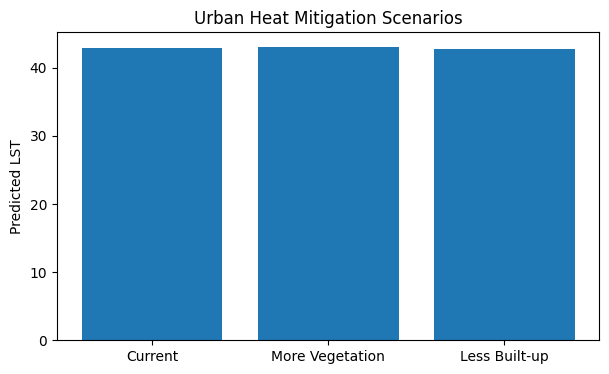

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.bar(
    scenario_results["Scenario"],
    scenario_results["Predicted_LST"]
)

plt.ylabel("Predicted LST")

plt.title("Urban Heat Mitigation Scenarios")

plt.show()